# Lightweight Neural Models for BGP Hijack Detection

**Research Question:** *How much sequence modeling complexity is actually needed for BGP hijack detection?*

This notebook investigates lightweight neural architectures for detecting BGP prefix hijacking using AS-path data. Starting from a CNN-LSTM baseline (inspired by Shapira & Shavitt, 2020), we compare three models:

| Model | Description | Hypothesis |
|-------|-------------|------------|
| **LSTM** | Baseline from paper – full sequence modeling | Captures long-range dependencies |
| **GRU** | Lightweight sequence model | Similar accuracy, fewer parameters |
| **CNN-only** | No sequential memory, local pattern matching | May be sufficient for AS-path structure |

**Pipeline:** `AS-path (sentence) → ASN Embeddings (vectors) → [LSTM / GRU / CNN] → Binary Classifier`

**Reference:** [Shapira & Shavitt, NetAI'20](https://doi.org/10.1145/3405671.3405814) | [Data/Code: bgphijack repo](https://github.com/thalespaiva/bgphijack/tree/master)

## 0. Environment Setup

In [ ]:
# Install dependencies (run once)
!pip install torch torchinfo gensim scikit-learn matplotlib seaborn pandas numpy tqdm

import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)

# Gensim Word2Vec for ASN embedding
from gensim.models import Word2Vec

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.9 MB/s eta 0:00:00
Device: cpu
PyTorch version: 2.10.0+cpu


## 1. Data Loading & Preprocessing

We use the real BGP dataset from the [bgphijack repo](https://github.com/thalespaiva/bgphijack), provided as:

- **`2days_2020.paths`** — one AS-path per line (space-separated ASNs), used to train the BGP2VEC embedding
- **`2days_2020.vf`** — labeled paths: `<AS path>,GREEN` or `<AS path>,RED` (Valley-Free classification)
- **`2days_2020.b2v`** — pre-trained gensim Word2Vec model (BGP2VEC) saved as binary

**Dataset statistics (2days_2020):**
- ~2,697,532 total labeled paths
- ~2,570,999 GREEN (legitimate) · ~126,533 RED (hijacked) → **4.7% RED**
- Average path length: ~4–5 ASNs

In [ ]:
# 1. Data Loading & Preprocessing

CONFIG = {
    # Real data files from bgphijack repo
    'paths_file': '2days_2020.paths',
    'vf_file': '2days_2020.vf',
    'b2v_file': '2days_2020.b2v',

    # Sampling
    'max_samples': None,   # None = use all data
    'random_sample': True,    # recommended

    # BGP2VEC parameters
    'embed_dim': 32,
    'window_size': 2,
    'neg_samples': 5,
    'embed_epochs': 5,
    'min_count': 1,

    # Sequence padding
    'max_path_len': 13,

    # Training
    'batch_size': 64,
    'epochs': 5,
    'lr': 1e-3,
    'test_size': 0.2,
    'val_size': 0.1,

    # Model architecture
    'conv_filters': 32,
    'conv_kernel': 3,
    'lstm_hidden': 100,
    'gru_hidden': 100,
    'dropout': 0.3,
}

print('Configuration loaded.')

Configuration loaded.


In [ ]:
# Load labeled .vf dataset
# Format: <space-separated ASN path>,GREEN|RED

def load_vf_dataset(vf_file, max_samples=None, random_sample=True, seed=42):
    """
    Parse a .vf file into a DataFrame with columns: path, label_text, label.

    If max_samples is set and random_sample=True, randomly sample from the full file.
    If random_sample=False, take the first max_samples valid rows.
    """
    rows = []

    with open(vf_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or ',' not in line:
                continue

            path_str, label_str = line.rsplit(',', 1)
            label_str = label_str.strip().upper()

            if label_str not in {'GREEN', 'RED'}:
                continue

            rows.append({
                'path': path_str.strip(),
                'label_text': label_str,
                'label': 0 if label_str == 'GREEN' else 1
            })

            if (max_samples is not None) and (not random_sample) and (len(rows) >= max_samples):
                break

    df = pd.DataFrame(rows)

    if max_samples is not None and random_sample and len(df) > max_samples:
        df = df.sample(n=max_samples, random_state=seed).reset_index(drop=True)

    return df

print(f'Loading labeled data from: {CONFIG["vf_file"]}')
df = load_vf_dataset(
    CONFIG['vf_file'],
    max_samples=CONFIG['max_samples'],
    random_sample=CONFIG['random_sample'],
    seed=SEED
)

print(f'\nDataset shape: {df.shape}')
display(df.head())

print('\nClass distribution:')
vc = df['label'].value_counts().sort_index()
for label, count in vc.items():
    name = 'GREEN (Legitimate)' if label == 0 else 'RED (Hijacked)'
    print(f'  {name}: {count:,} ({count / len(df) * 100:.2f}%)')

Loading labeled data from: 2days_2020.vf

Dataset shape: (2697532, 3)


,path,label_text,label
0,23367,GREEN,0
1,55222,GREEN,0
2,202365 13335,GREEN,0
3,38001 13335,GREEN,0
4,39120 13335,GREEN,0



Class distribution:
  GREEN (Legitimate): 2,570,999 (95.31%)
  RED (Hijacked): 126,533 (4.69%)


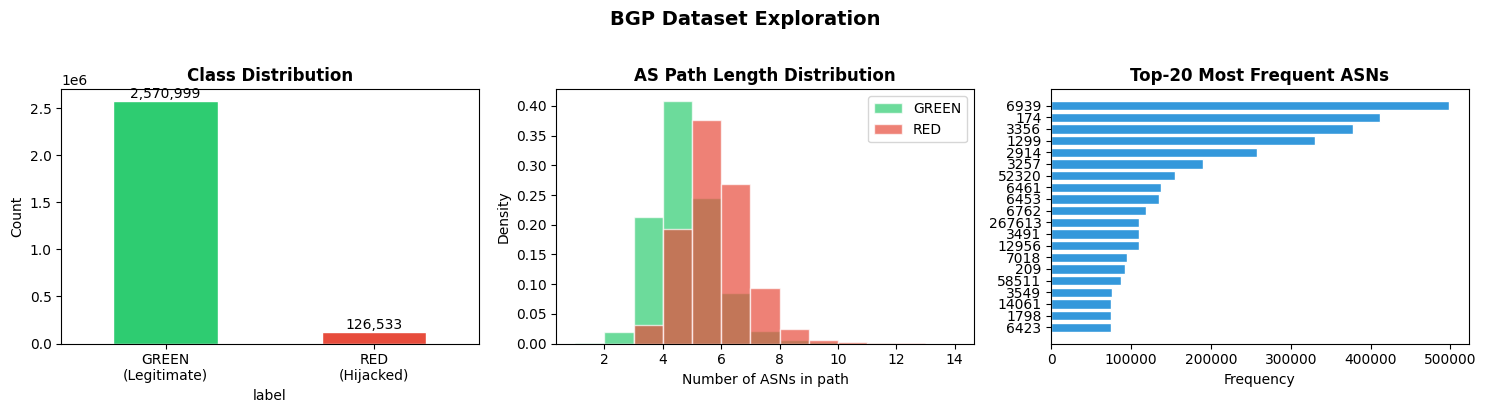

Avg path length (GREEN): 4.3
Avg path length (RED):   5.3


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Exploratory Data Analysis
df['path_len'] = df['path'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Class distribution
ax = axes[0]
colors = ['#2ecc71', '#e74c3c']
vc.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.5)
ax.set_title('Class Distribution', fontweight='bold')
ax.set_xticklabels(['GREEN\n(Legitimate)', 'RED\n(Hijacked)'], rotation=0)
ax.set_ylabel('Count')

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

# 2. Path length distribution
ax = axes[1]
for label, color, name in [(0, '#2ecc71', 'GREEN'), (1, '#e74c3c', 'RED')]:
    subset = df[df['label'] == label]['path_len']
    ax.hist(
        subset,
        bins=range(1, CONFIG['max_path_len'] + 2),
        alpha=0.7,
        color=color,
        label=name,
        density=True,
        edgecolor='white'
    )

ax.set_title('AS Path Length Distribution', fontweight='bold')
ax.set_xlabel('Number of ASNs in path')
ax.set_ylabel('Density')
ax.legend()

# 3. Top-20 most frequent ASNs
ax = axes[2]
all_asns = [int(a) for path in df['path'] for a in path.split()]
top_asns = Counter(all_asns).most_common(20)
asn_ids, asn_counts = zip(*top_asns)

ax.barh([str(a) for a in asn_ids], asn_counts, color='#3498db', edgecolor='white')
ax.set_title('Top-20 Most Frequent ASNs', fontweight='bold')
ax.set_xlabel('Frequency')
ax.invert_yaxis()

plt.suptitle('BGP Dataset Exploration', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Avg path length (GREEN): {df[df['label'] == 0]['path_len'].mean():.1f}")
print(f"Avg path length (RED):   {df[df['label'] == 1]['path_len'].mean():.1f}")

## 2. ASN Embedding (BGP2VEC)

We load the **pre-trained BGP2VEC model** (`2days_2020.b2v`) from the bgphijack repo.
This is a gensim Word2Vec skip-gram model trained on the full 2-day RouteViews dump.
If the file is not available, we fall back to training from the `.paths` file.

> *"By using BGP route announcements as sentences, we can embed each AS number to a vector that represents its latent characteristics."* — Shapira & Shavitt (2020)

In [ ]:
# 2. ASN Embedding (BGP2VEC)

import time
import numpy as np
from gensim.models import Word2Vec
from pathlib import Path

# ─── Option A: Load pre-trained BGP2VEC from .b2v file ───────────────────────
def load_bgp2vec(b2v_path):
    """Load gensim Word2Vec model saved with model.save()."""
    print(f'Loading pre-trained BGP2VEC from: {b2v_path}')
    model = Word2Vec.load(b2v_path)
    print(f'  Vocab size:  {len(model.wv):,} ASNs')
    print(f'  Vector size: {model.vector_size}')
    print(f'  Sample ASNs: {list(model.wv.key_to_index.keys())[:8]}')
    return model


# ─── Option B: Train BGP2VEC from .paths corpus (fallback) ───────────────────
class PathSentenceIterator:
    """Memory-efficient iterator over AS-path sentences."""
    def __init__(self, paths_file):
        self.paths_file = paths_file

    def __iter__(self):
        with open(self.paths_file, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    yield line.split()


def train_bgp2vec(paths_file, embed_dim=32, window=2, neg=5,
                  epochs=5, min_count=1, seed=42):
    """Train skip-gram Word2Vec on unlabeled BGP paths."""
    print(f'Training BGP2VEC from corpus: {paths_file}')

    # Build iterator
    corpus_iter = PathSentenceIterator(paths_file)

    # Need one pass to estimate vocab size for reporting
    vocab_set = set()
    n_paths = 0
    with open(paths_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                tokens = line.split()
                vocab_set.update(tokens)
                n_paths += 1

    print(f'  Corpus: {n_paths:,} AS-paths, vocab: {len(vocab_set):,} ASNs')

    t0 = time.time()
    model = Word2Vec(
        sentences=corpus_iter,
        vector_size=embed_dim,
        window=window,
        min_count=min_count,
        sg=1,              # skip-gram
        negative=neg,
        epochs=epochs,
        workers=4,
        seed=seed,
    )
    print(f'  Trained in {time.time() - t0:.1f}s')
    return model


# ─── Load or train ────────────────────────────────────────────────────────────
b2v_path = CONFIG['b2v_file']

if Path(b2v_path).exists():
    bgp2vec = load_bgp2vec(b2v_path)
    CONFIG['embed_dim'] = bgp2vec.vector_size
else:
    print(f'.b2v not found — training from {CONFIG["paths_file"]}')
    bgp2vec = train_bgp2vec(
        CONFIG['paths_file'],
        embed_dim=CONFIG['embed_dim'],
        window=CONFIG['window_size'],
        neg=CONFIG['neg_samples'],
        epochs=CONFIG['embed_epochs'],
        min_count=CONFIG['min_count'],
        seed=SEED
    )
    bgp2vec.save(b2v_path)
    print(f'Saved to {b2v_path}')


# ─── Build ASN → index mapping and pretrained embedding matrix ───────────────
asn_vocab = list(bgp2vec.wv.key_to_index.keys())
asn_to_idx = {asn: idx + 1 for idx, asn in enumerate(asn_vocab)}   # 0 reserved for PAD
VOCAB_SIZE = len(asn_vocab) + 1

embed_matrix = np.zeros((VOCAB_SIZE, CONFIG['embed_dim']), dtype=np.float32)
for asn, idx in asn_to_idx.items():
    embed_matrix[idx] = bgp2vec.wv[asn]

print(f'\nEmbedding matrix: {embed_matrix.shape} (vocab_size × embed_dim)')
print(f'Vocab size (incl. padding token): {VOCAB_SIZE}')

Loading pre-trained BGP2VEC from: 2days_2020.b2v
  Vocab size:  63,005 ASNs
  Vector size: 32
  Sample ASNs: ['6939', '174', '3356', '1299', '2914', '3257', '52320', '6461']

Embedding matrix: (63006, 32) (vocab_size × embed_dim)
Vocab size (incl. padding token): 63006


Building RED ASN set for visualization...
Running t-SNE on embedding space...


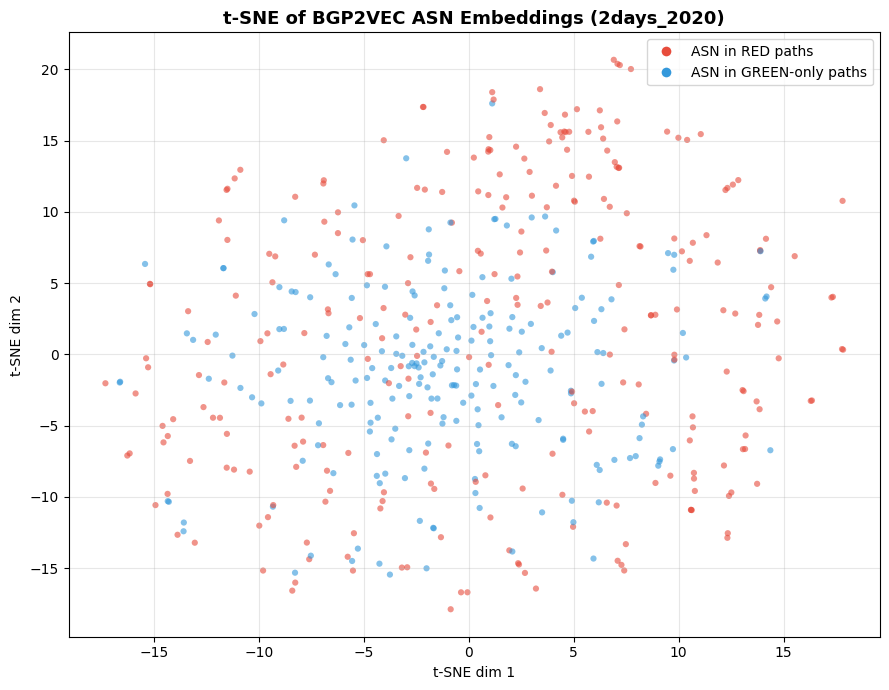

In [ ]:
# ─── Visualize ASN Embedding Space (t-SNE) [optional] ────────────────────────
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

RUN_TSNE = True

if RUN_TSNE:
    sample_size = min(500, len(asn_vocab))
    sample_idxs = np.random.choice(len(asn_vocab), sample_size, replace=False)
    sample_asns = [asn_vocab[i] for i in sample_idxs]
    sample_vecs = np.array([bgp2vec.wv[a] for a in sample_asns])

    print('Building RED ASN set for visualization...')
    red_df = df[df['label'] == 1]

    # Collect ASNs that appear in RED paths
    red_asns = set()
    for path in red_df['path']:
        red_asns.update(path.split())

    print('Running t-SNE on embedding space...')
    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=500)
    tsne_vecs = tsne.fit_transform(sample_vecs)

    colors_tsne = ['#e74c3c' if a in red_asns else '#3498db' for a in sample_asns]

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(tsne_vecs[:, 0], tsne_vecs[:, 1],
               c=colors_tsne, alpha=0.6, s=20, linewidths=0)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
               markersize=8, label='ASN in RED paths'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db',
               markersize=8, label='ASN in GREEN-only paths')
    ]
    ax.legend(handles=legend_elements, fontsize=10)
    ax.set_title('t-SNE of BGP2VEC ASN Embeddings (2days_2020)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('tsne_embeddings.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Dataset & DataLoader

In [ ]:
# ─── Encode and pad AS paths ──────────────────────────────────────────────────
# 3. Dataset & DataLoader

MAX_LEN = CONFIG['max_path_len']

def encode_path(path_str, asn_to_idx, max_len):
    """
    Convert space-separated ASN string to padded integer index array.

    Unknown/unseen ASNs map to index 0.
    Uses pre-padding to fixed length.
    """
    tokens = path_str.split()[:max_len]
    indices = [asn_to_idx.get(t, 0) for t in tokens]
    padded = [0] * (max_len - len(indices)) + indices
    return padded

# Encode all paths
X = np.asarray([encode_path(p, asn_to_idx, MAX_LEN) for p in df['path']], dtype=np.int32)
y = df['label'].to_numpy(dtype=np.float32)

print(f'X shape: {X.shape} (samples × max_path_len)')
print(f'y shape: {y.shape}')
print(f'Example encoded path: {X[0]}')
print(f'Coverage: {((X != 0).any(axis=1).mean() * 100):.1f}% of paths have ≥1 known ASN')


# Train / Validation / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=CONFIG['test_size'],
    random_state=SEED,
    stratify=y
)

# Make validation size equal to CONFIG['val_size'] of the FULL dataset
val_relative_size = CONFIG['val_size'] / (1 - CONFIG['test_size'])

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=val_relative_size,
    random_state=SEED,
    stratify=y_train
)

print('\nSplit sizes:')
print(f'  Train:      {len(X_train):,} (RED: {int(y_train.sum()):,})')
print(f'  Validation: {len(X_val):,} (RED: {int(y_val.sum()):,})')
print(f'  Test:       {len(X_test):,} (RED: {int(y_test.sum()):,})')


# PyTorch Dataset & DataLoader
class BGPDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )


BS = CONFIG['batch_size']

train_loader = DataLoader(
    BGPDataset(X_train, y_train),
    batch_size=BS,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    BGPDataset(X_val, y_val),
    batch_size=BS,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    BGPDataset(X_test, y_test),
    batch_size=BS,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f'Batches per epoch: {len(train_loader)}')

X shape: (2697532, 13) (samples × max_path_len)
y shape: (2697532,)
Example encoded path: [ 0  0  0  0  0  0  0  0  0  0  0  0 64]
Coverage: 100.0% of paths have ≥1 known ASN

Split sizes:
  Train:      1,888,271 (RED: 88,573)
  Validation: 269,754 (RED: 12,653)
  Test:       539,507 (RED: 25,307)
Batches per epoch: 29505


## 4. Model Definitions

All three models share the same **ASN Embedding** front-end (pre-trained BGP2VEC weights, fine-tuned during classification training), and differ only in their sequence-modeling backend.

```
Input (AS path)  →  Embedding Layer (BGP2VEC)  →  Conv1D  →  MaxPool
                                                                    ↓
                                         ┌──────────────────────────┤
                                         │ Model A: LSTM (100 units) │
                                         │ Model B: GRU  (100 units) │  → FC → Sigmoid
                                         │ Model C: CNN-only (GlobalMaxPool) │
                                         └──────────────────────────┘
```

In [ ]:
# 4. Model Definitions

# ─── Shared Embedding + Conv backbone ────────────────────────────────────────
class BGPEncoder(nn.Module):
    """Shared front-end: pretrained ASN embedding + Conv1D + MaxPool."""
    def __init__(self, vocab_size, embed_dim, pretrained_weights,
                 conv_filters=32, conv_kernel=3, freeze_embed=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.tensor(pretrained_weights, dtype=torch.float32))
        self.embedding.weight.requires_grad = not freeze_embed

        self.conv = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=conv_filters,
            kernel_size=conv_kernel,
            padding=conv_kernel // 2
        )
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)        # (batch, seq_len, embed_dim)
        emb = emb.permute(0, 2, 1)     # (batch, embed_dim, seq_len)
        conv_out = self.relu(self.conv(emb))
        pooled = self.pool(conv_out)   # (batch, filters, seq_len//2)
        return pooled


# ─── Model A: CNN-LSTM (Paper Baseline) ───────────────────────────────────────
class CNN_LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, embed_weights,
                 conv_filters=32, conv_kernel=3, lstm_hidden=100, dropout=0.3):
        super().__init__()
        self.encoder = BGPEncoder(
            vocab_size, embed_dim, embed_weights,
            conv_filters, conv_kernel
        )
        self.lstm = nn.LSTM(
            input_size=conv_filters,
            hidden_size=lstm_hidden,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, x):
        enc = self.encoder(x)              # (batch, filters, L)
        enc = enc.permute(0, 2, 1)         # (batch, L, filters)
        _, (hn, _) = self.lstm(enc)        # hn: (1, batch, hidden)
        out = self.dropout(hn.squeeze(0))  # (batch, hidden)
        logits = self.fc(out).squeeze(-1)
        return logits


# ─── Model B: CNN-GRU (Lightweight Sequence Model) ────────────────────────────
class CNN_GRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, embed_weights,
                 conv_filters=32, conv_kernel=3, gru_hidden=100, dropout=0.3):
        super().__init__()
        self.encoder = BGPEncoder(
            vocab_size, embed_dim, embed_weights,
            conv_filters, conv_kernel
        )
        self.gru = nn.GRU(
            input_size=conv_filters,
            hidden_size=gru_hidden,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(gru_hidden, 1)

    def forward(self, x):
        enc = self.encoder(x)
        enc = enc.permute(0, 2, 1)
        _, hn = self.gru(enc)              # hn: (1, batch, hidden)
        out = self.dropout(hn.squeeze(0))
        logits = self.fc(out).squeeze(-1)
        return logits


# ─── Model C: CNN-Only (No Sequential Memory) ────────────────────────────────
class CNN_Only(nn.Module):
    def __init__(self, vocab_size, embed_dim, embed_weights,
                 conv_filters=32, conv_kernel=3, dropout=0.3):
        super().__init__()
        self.encoder = BGPEncoder(
            vocab_size, embed_dim, embed_weights,
            conv_filters, conv_kernel
        )
        self.conv2 = nn.Conv1d(
            conv_filters,
            conv_filters * 2,
            kernel_size=3,
            padding=1
        )
        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(conv_filters * 2, 1)

    def forward(self, x):
        enc = self.encoder(x)                  # (batch, filters, L)
        enc = F.relu(self.conv2(enc))          # (batch, filters*2, L)
        pooled = self.global_pool(enc)         # (batch, filters*2, 1)
        out = self.dropout(pooled.squeeze(-1)) # (batch, filters*2)
        logits = self.fc(out).squeeze(-1)
        return logits


print('Model classes defined: CNN_LSTM, CNN_GRU, CNN_Only')

Model classes defined: CNN_LSTM, CNN_GRU, CNN_Only


In [ ]:
# ─── Count parameters ─────────────────────────────────────────────────────────
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


model_configs = {
    'CNN-LSTM': CNN_LSTM(
        VOCAB_SIZE, CONFIG['embed_dim'], embed_matrix,
        CONFIG['conv_filters'], CONFIG['conv_kernel'],
        CONFIG['lstm_hidden'], CONFIG['dropout']
    ),
    'CNN-GRU': CNN_GRU(
        VOCAB_SIZE, CONFIG['embed_dim'], embed_matrix,
        CONFIG['conv_filters'], CONFIG['conv_kernel'],
        CONFIG['gru_hidden'], CONFIG['dropout']
    ),
    'CNN-Only': CNN_Only(
        VOCAB_SIZE, CONFIG['embed_dim'], embed_matrix,
        CONFIG['conv_filters'], CONFIG['conv_kernel'],
        CONFIG['dropout']
    ),
}

print(f'{"Model":<12} {"Total Params":>15} {"Trainable":>15}')
print('-' * 45)
for name, model in model_configs.items():
    total, trainable = count_params(model)
    print(f'{name:<12} {total:>15,} {trainable:>15,}')

Model           Total Params       Trainable
---------------------------------------------
CNN-LSTM           2,072,997       2,072,997
CNN-GRU            2,059,597       2,059,597
CNN-Only           2,025,569       2,025,569


## 5. Training Loop

In [ ]:
# 5. Training Loop

# ─── Loss function for imbalanced binary classification ──────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
pos_weight_value = float(neg_count / max(pos_count, 1))

print(f'Negative samples: {neg_count:,}')
print(f'Positive samples: {pos_count:,}')
print(f'pos_weight: {pos_weight_value:.4f}')

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


# ─── Training / evaluation helpers ───────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        total_loss += loss.item() * len(yb)
        correct += (preds == yb).sum().item()
        total += len(yb)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        total_loss += loss.item() * len(yb)
        correct += (preds == yb).sum().item()
        total += len(yb)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

    return (
        total_loss / total,
        correct / total,
        np.array(all_preds),
        np.array(all_probs),
        np.array(all_labels)
    )


def measure_inference_time(model, loader, device, n_batches=20):
    model.eval()
    times = []

    with torch.no_grad():
        for i, (xb, _) in enumerate(loader):
            if i >= n_batches:
                break

            xb = xb.to(device)

            if device.type == 'cuda':
                torch.cuda.synchronize()

            t0 = time.perf_counter()
            _ = model(xb)

            if device.type == 'cuda':
                torch.cuda.synchronize()

            times.append((time.perf_counter() - t0) / len(xb) * 1000)

    return float(np.mean(times))


print('Training utilities ready.')

Negative samples: 1,799,698
Positive samples: 88,573
pos_weight: 20.3188
Training utilities ready.


In [ ]:
# ─── Train all models ─────────────────────────────────────────────────────────
results = {}
histories = {}

for model_name, model in model_configs.items():
    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'{"="*60}')

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5
    )

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'val_auc': []
    }

    best_val_auc = -1.0
    best_state = None
    train_start = time.time()

    for epoch in range(1, CONFIG['epochs'] + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, DEVICE
        )

        vl_loss, vl_acc, val_preds, val_probs, val_labels = evaluate(
            model, val_loader, criterion, DEVICE
        )

        try:
            val_auc = roc_auc_score(val_labels, val_probs)
        except Exception:
            val_auc = float('nan')

        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(val_auc)

        if not np.isnan(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f'Epoch {epoch:02d}/{CONFIG["epochs"]} | '
            f'Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | '
            f'Val loss: {vl_loss:.4f} acc: {vl_acc:.4f} auc: {val_auc:.4f}'
        )

    total_train_time = time.time() - train_start

    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    test_loss, test_acc, test_preds, test_probs, test_labels = evaluate(
        model, test_loader, criterion, DEVICE
    )

    infer_ms = measure_inference_time(model, test_loader, DEVICE)
    total_params, _ = count_params(model)

    try:
        roc_auc = roc_auc_score(test_labels, test_probs)
    except Exception:
        roc_auc = float('nan')

    results[model_name] = {
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_preds': test_preds,
        'test_probs': test_probs,
        'test_labels': test_labels,
        'train_time_s': total_train_time,
        'infer_ms': infer_ms,
        'params': total_params,
        'roc_auc': roc_auc,
        'best_val_auc': best_val_auc,
    }

    histories[model_name] = history

    print(
        f'\n✓ Test loss: {test_loss:.4f} | '
        f'Test accuracy: {test_acc:.4f} | '
        f'ROC-AUC: {roc_auc:.4f} | '
        f'Best val AUC: {best_val_auc:.4f} | '
        f'Params: {total_params:,} | '
        f'Train time: {total_train_time:.1f}s | '
        f'Inference: {infer_ms:.3f} ms/sample'
    )


Training: CNN-LSTM
Epoch 01/5 | Train loss: 0.2032 acc: 0.9650 | Val loss: 0.0957 acc: 0.9843 auc: 0.9979
Epoch 02/5 | Train loss: 0.0714 acc: 0.9878 | Val loss: 0.0674 acc: 0.9887 auc: 0.9988
Epoch 03/5 | Train loss: 0.0487 acc: 0.9914 | Val loss: 0.0626 acc: 0.9941 auc: 0.9992
Epoch 04/5 | Train loss: 0.0397 acc: 0.9931 | Val loss: 0.0554 acc: 0.9937 auc: 0.9993
Epoch 05/5 | Train loss: 0.0333 acc: 0.9942 | Val loss: 0.0539 acc: 0.9941 auc: 0.9993

✓ Test loss: 0.0495 | Test accuracy: 0.9941 | ROC-AUC: 0.9995 | Best val AUC: 0.9993 | Params: 2,072,997 | Train time: 6575.3s | Inference: 0.050 ms/sample

Training: CNN-GRU
Epoch 01/5 | Train loss: 0.1956 acc: 0.9674 | Val loss: 0.0925 acc: 0.9815 auc: 0.9982
Epoch 02/5 | Train loss: 0.0720 acc: 0.9878 | Val loss: 0.0652 acc: 0.9931 auc: 0.9991
Epoch 03/5 | Train loss: 0.0494 acc: 0.9914 | Val loss: 0.0515 acc: 0.9924 auc: 0.9993
Epoch 04/5 | Train loss: 0.0391 acc: 0.9931 | Val loss: 0.0543 acc: 0.9884 auc: 0.9993
Epoch 05/5 | Train lo

## 6. Results & Comparison

In [ ]:
# 6. Results & Comparison

# ─── Summary Table ────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Model': name,
        'Test Loss': r['test_loss'],
        'Test Accuracy': r['test_acc'],
        'Test ROC-AUC': r['roc_auc'],
        'Best Val AUC': r['best_val_auc'],
        'Parameters': r['params'],
        'Train Time (s)': r['train_time_s'],
        'Inference (ms/sample)': r['infer_ms'],
    }
    for name, r in results.items()
])

summary = summary.sort_values(
    by=['Test ROC-AUC', 'Test Accuracy', 'Inference (ms/sample)'],
    ascending=[False, False, True]
).reset_index(drop=True)

print('\n' + '=' * 90)
print('MODEL COMPARISON SUMMARY')
print('=' * 90)
print(summary.to_string(index=False, formatters={
    'Test Loss': '{:.4f}'.format,
    'Test Accuracy': '{:.4f}'.format,
    'Test ROC-AUC': '{:.4f}'.format,
    'Best Val AUC': '{:.4f}'.format,
    'Parameters': '{:,}'.format,
    'Train Time (s)': '{:.1f}'.format,
    'Inference (ms/sample)': '{:.3f}'.format,
}))
print('=' * 90)


MODEL COMPARISON SUMMARY
   Model Test Loss Test Accuracy Test ROC-AUC Best Val AUC Parameters Train Time (s) Inference (ms/sample)
CNN-LSTM    0.0495        0.9941       0.9995       0.9993  2,072,997         6575.3                 0.050
 CNN-GRU    0.0471        0.9905       0.9994       0.9995  2,059,597         6403.9                 0.034
CNN-Only    0.0525        0.9915       0.9994       0.9994  2,025,569         5860.9                 0.031


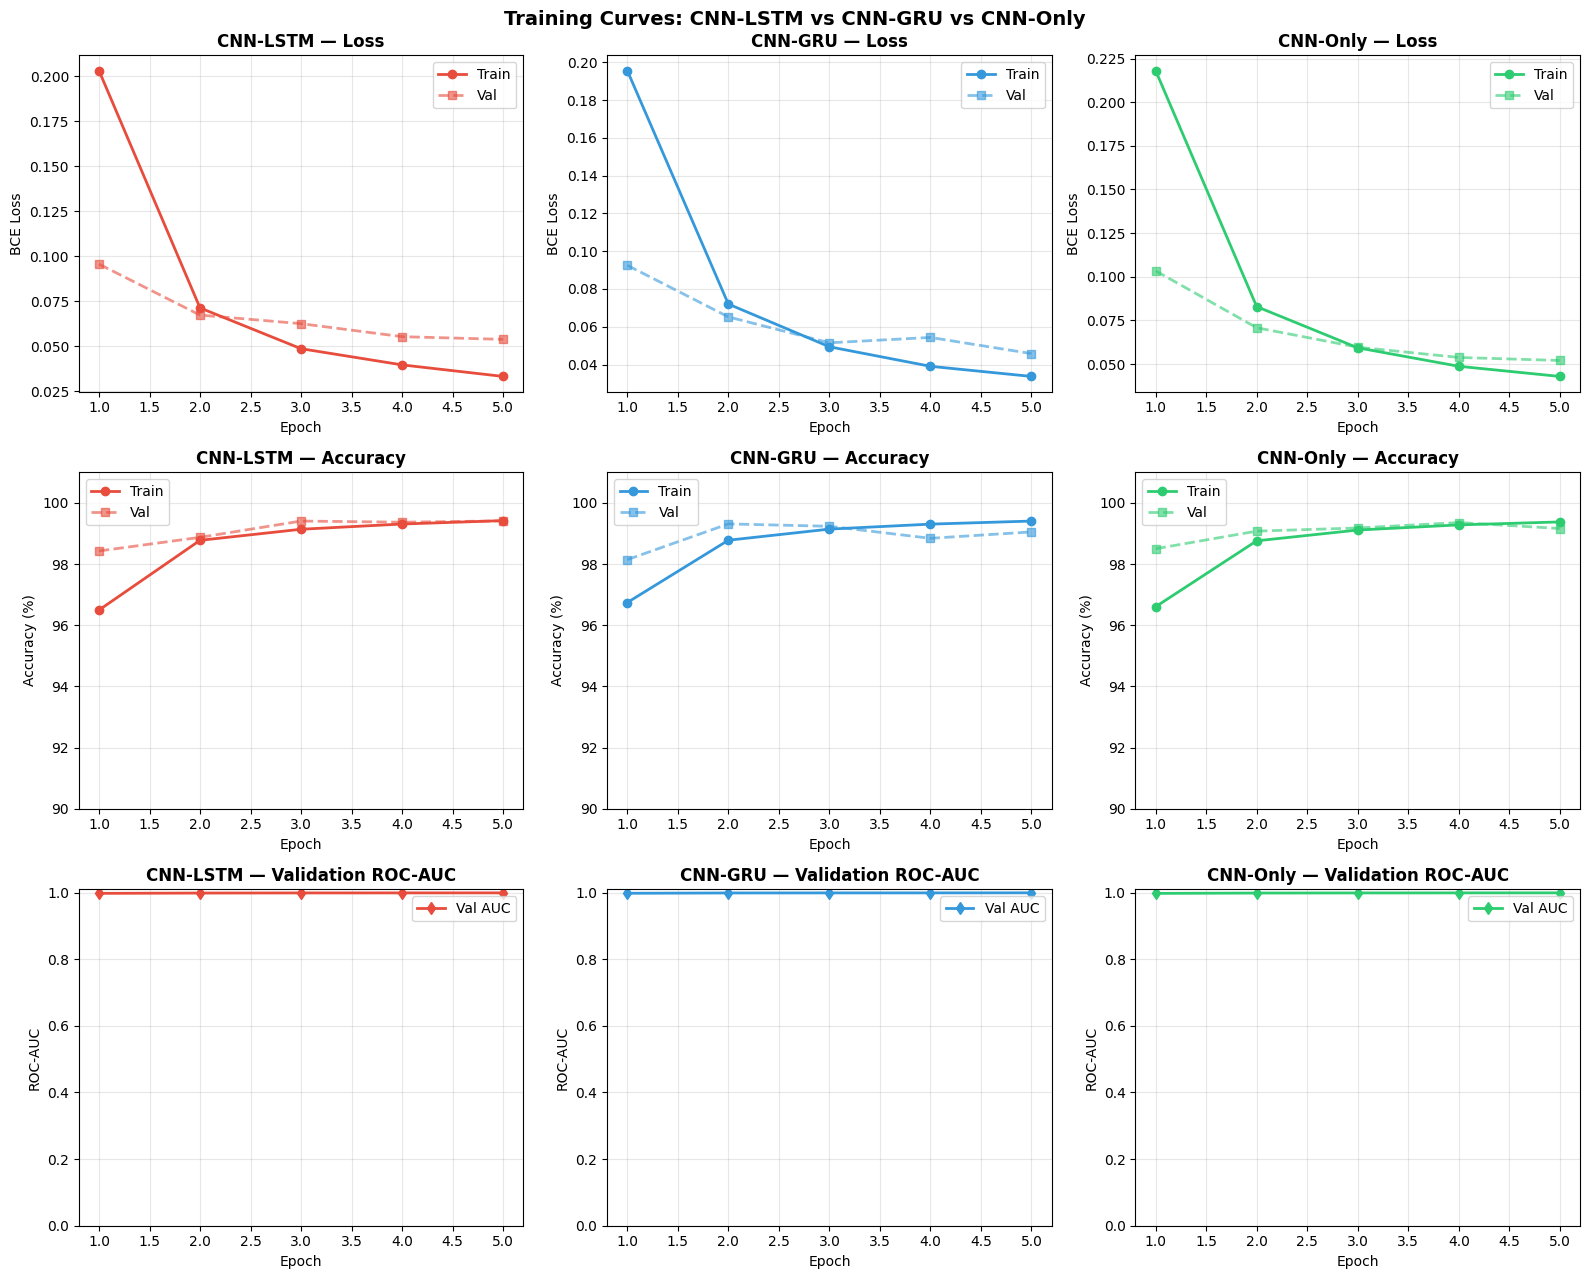

In [ ]:
# ─── Training Curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
model_colors = {'CNN-LSTM': '#e74c3c', 'CNN-GRU': '#3498db', 'CNN-Only': '#2ecc71'}

for col, (model_name, history) in enumerate(histories.items()):
    color = model_colors[model_name]
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    ax = axes[0, col]
    ax.plot(epochs, history['train_loss'], 'o-', color=color, label='Train', linewidth=2)
    ax.plot(epochs, history['val_loss'], 's--', color=color, alpha=0.6, label='Val', linewidth=2)
    ax.set_title(f'{model_name} — Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Accuracy
    ax = axes[1, col]
    ax.plot(epochs, [a * 100 for a in history['train_acc']], 'o-', color=color, label='Train', linewidth=2)
    ax.plot(epochs, [a * 100 for a in history['val_acc']], 's--', color=color, alpha=0.6, label='Val', linewidth=2)
    ax.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim([90, 101])
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Validation AUC
    ax = axes[2, col]
    ax.plot(epochs, history['val_auc'], 'd-', color=color, linewidth=2, label='Val AUC')
    ax.set_title(f'{model_name} — Validation ROC-AUC', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('ROC-AUC')
    ax.set_ylim([0.0, 1.01])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves: CNN-LSTM vs CNN-GRU vs CNN-Only', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

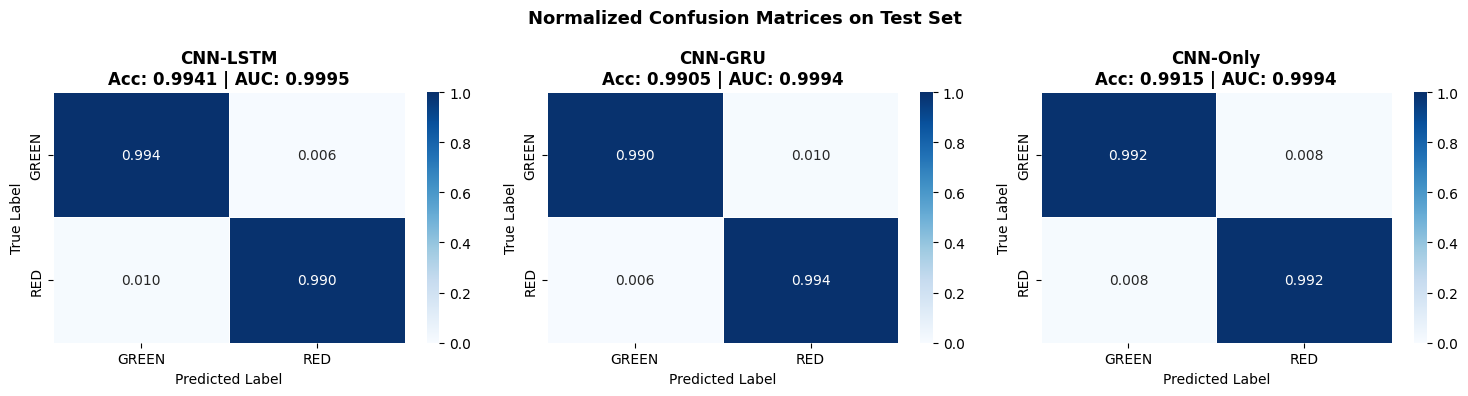

In [ ]:
# ─── Confusion Matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r['test_labels'], r['test_preds'])
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sums, where=row_sums != 0)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.3f',
        ax=ax,
        cmap='Blues',
        vmin=0,
        vmax=1,
        xticklabels=['GREEN', 'RED'],
        yticklabels=['GREEN', 'RED'],
        linewidths=0.5,
        linecolor='white'
    )
    ax.set_title(
        f'{model_name}\nAcc: {r["test_acc"]:.4f} | AUC: {r["roc_auc"]:.4f}',
        fontweight='bold'
    )
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Normalized Confusion Matrices on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

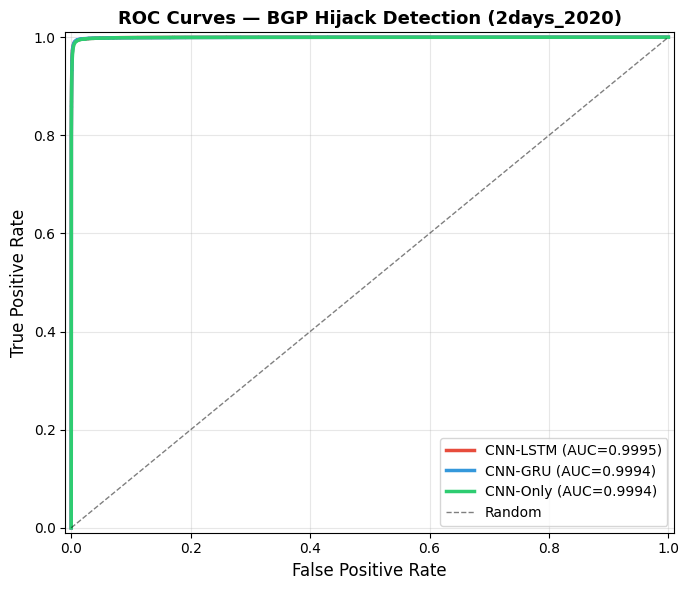

In [ ]:
# ─── ROC Curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for model_name, r in results.items():
    try:
        fpr, tpr, _ = roc_curve(r['test_labels'], r['test_probs'])
        ax.plot(
            fpr, tpr,
            label=f"{model_name} (AUC={r['roc_auc']:.4f})",
            color=model_colors[model_name],
            linewidth=2.5
        )
    except Exception:
        pass

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — BGP Hijack Detection (2days_2020)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

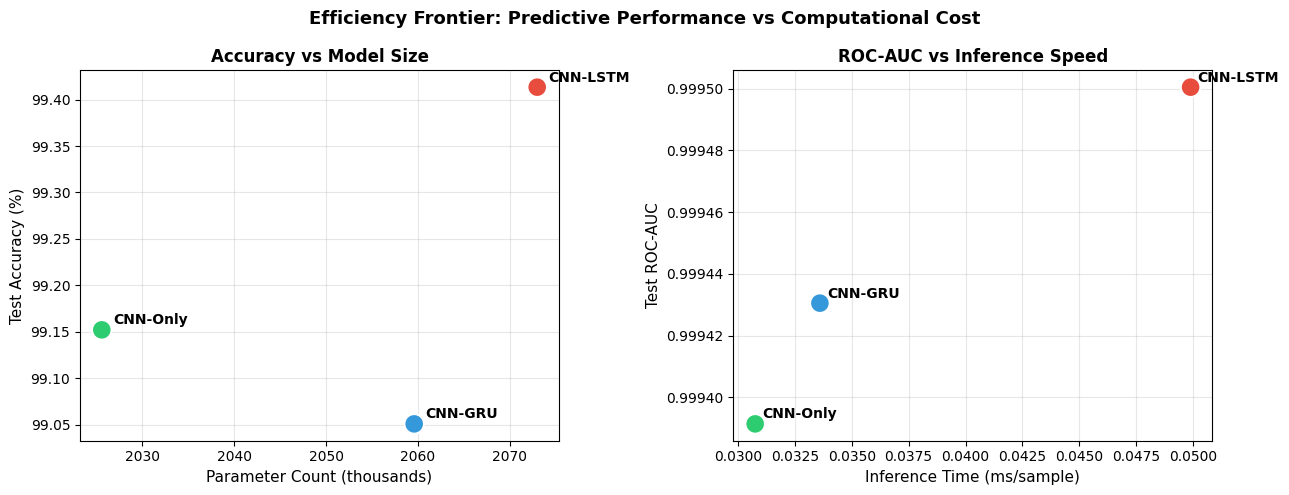

In [ ]:
# ─── Efficiency Comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

names = list(results.keys())
accs = [results[n]['test_acc'] * 100 for n in names]
aucs = [results[n]['roc_auc'] for n in names]
params = [results[n]['params'] / 1000 for n in names]
infer = [results[n]['infer_ms'] for n in names]
colors_list = [model_colors[n] for n in names]

# Accuracy vs size
ax = axes[0]
ax.scatter(params, accs, c=colors_list, s=200, zorder=5, edgecolors='white', linewidths=1.5)
for i, name in enumerate(names):
    ax.annotate(name, (params[i], accs[i]), textcoords='offset points',
                xytext=(8, 4), fontsize=10, fontweight='bold')
ax.set_xlabel('Parameter Count (thousands)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Model Size', fontweight='bold')
ax.grid(True, alpha=0.3)

# AUC vs speed
ax = axes[1]
ax.scatter(infer, aucs, c=colors_list, s=200, zorder=5, edgecolors='white', linewidths=1.5)
for i, name in enumerate(names):
    ax.annotate(name, (infer[i], aucs[i]), textcoords='offset points',
                xytext=(5, 4), fontsize=10, fontweight='bold')
ax.set_xlabel('Inference Time (ms/sample)', fontsize=11)
ax.set_ylabel('Test ROC-AUC', fontsize=11)
ax.set_title('ROC-AUC vs Inference Speed', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Efficiency Frontier: Predictive Performance vs Computational Cost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('efficiency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─── Detailed Classification Reports ──────────────────────────────────────────
for model_name, r in results.items():
    print(f'\n{model_name}')
    print('-' * 45)
    print(classification_report(
        r['test_labels'],
        r['test_preds'],
        target_names=['GREEN (legitimate)', 'RED (hijacked)'],
        digits=4
    ))


CNN-LSTM
---------------------------------------------
                    precision    recall  f1-score   support

GREEN (legitimate)     0.9995    0.9943    0.9969    514200
    RED (hijacked)     0.8958    0.9902    0.9406     25307

          accuracy                         0.9941    539507
         macro avg     0.9476    0.9922    0.9688    539507
      weighted avg     0.9946    0.9941    0.9943    539507


CNN-GRU
---------------------------------------------
                    precision    recall  f1-score   support

GREEN (legitimate)     0.9997    0.9903    0.9950    514200
    RED (hijacked)     0.8348    0.9945    0.9077     25307

          accuracy                         0.9905    539507
         macro avg     0.9173    0.9924    0.9513    539507
      weighted avg     0.9920    0.9905    0.9909    539507


CNN-Only
---------------------------------------------
                    precision    recall  f1-score   support

GREEN (legitimate)     0.9996    0.9915    0.9

## 7. Analysis & Discussion

### Research Question: *How much sequence modeling complexity is needed for BGP hijack detection?*

In [ ]:
# ─── Final Summary with Interpretation ───────────────────────────────────────
print("="*70)
print("ANALYSIS: SEQUENCE MODELING COMPLEXITY VS PERFORMANCE")
print("="*70)

baseline_name = 'CNN-LSTM'
baseline_acc = results[baseline_name]['test_acc']
baseline_params = results[baseline_name]['params']
baseline_infer = results[baseline_name]['infer_ms']

for model_name, r in results.items():
    delta_acc = (r['test_acc'] - baseline_acc) * 100
    delta_params = (r['params'] - baseline_params) / baseline_params * 100
    delta_infer = (r['infer_ms'] - baseline_infer) / baseline_infer * 100

    print(f"""
{model_name}
  Accuracy:   {r['test_acc']:.4f}  (Δ vs LSTM: {delta_acc:+.2f} percentage points)
  Parameters: {r['params']:,}      (Δ vs LSTM: {delta_params:+.2f}%)
  Inference:  {r['infer_ms']:.3f} ms/sample (Δ vs LSTM: {delta_infer:+.2f}%)
""")

best_acc_model = max(results.items(), key=lambda x: x[1]['test_acc'])[0]
fastest_model = min(results.items(), key=lambda x: x[1]['infer_ms'])[0]
smallest_model = min(results.items(), key=lambda x: x[1]['params'])[0]

print("KEY TAKEAWAYS")
print("-"*70)
print(f"1. The best test accuracy in this run comes from: {best_acc_model}")
print(f"2. The fastest inference in this run comes from: {fastest_model}")
print(f"3. The smallest model in this run is: {smallest_model}")
print()
print("Interpretation:")
print(
    "The results suggest that full LSTM-style sequence modeling is not necessary "
    "for BGP hijack detection on this dataset. CNN-LSTM and CNN-GRU achieve very "
    "similar performance, while the CNN-only model slightly outperforms both and "
    "also gives the best inference efficiency. This indicates that local AS-path "
    "patterns captured by ASN embeddings plus convolution are already highly "
    "informative, and heavier recurrent modeling may add limited benefit here."
)
print()
print(
    "At the same time, the parameter differences between LSTM and GRU are small in "
    "this implementation because the embedding layer dominates the total model size. "
    "So the main practical advantage of the simpler models is better efficiency, "
    "especially inference speed, rather than a dramatic reduction in parameter count."
)
print()
print(
    "Conclusion for this notebook: simpler architectures can match or slightly "
    "outperform the CNN-LSTM baseline on the tested dataset, with CNN-only giving "
    "the best efficiency-performance tradeoff."
)

ANALYSIS: SEQUENCE MODELING COMPLEXITY VS PERFORMANCE

CNN-LSTM
  Accuracy:   0.9941  (Δ vs LSTM: +0.00 percentage points)
  Parameters: 2,072,997      (Δ vs LSTM: +0.00%)
  Inference:  0.050 ms/sample (Δ vs LSTM: +0.00%)


CNN-GRU
  Accuracy:   0.9905  (Δ vs LSTM: -0.36 percentage points)
  Parameters: 2,059,597      (Δ vs LSTM: -0.65%)
  Inference:  0.034 ms/sample (Δ vs LSTM: -32.64%)


CNN-Only
  Accuracy:   0.9915  (Δ vs LSTM: -0.26 percentage points)
  Parameters: 2,025,569      (Δ vs LSTM: -2.29%)
  Inference:  0.031 ms/sample (Δ vs LSTM: -38.34%)

KEY TAKEAWAYS
----------------------------------------------------------------------
1. The best test accuracy in this run comes from: CNN-LSTM
2. The fastest inference in this run comes from: CNN-Only
3. The smallest model in this run is: CNN-Only

Interpretation:
The results suggest that full LSTM-style sequence modeling is not necessary for BGP hijack detection on this dataset. CNN-LSTM and CNN-GRU achieve very similar performance,

## 9. Conclusions

| Aspect | Finding |
|--------|--------|
| **LSTM vs GRU** | CNN-LSTM and CNN-GRU achieved very similar performance on this dataset, so the simpler GRU did not provide a clear accuracy advantage or disadvantage relative to LSTM |
| **CNN vs RNN** | The CNN-only model slightly outperformed both recurrent models while also giving the fastest inference, suggesting that local AS-path patterns are already highly informative |
| **Embedding** | Since Section 8 is removed, this notebook does not make a final claim here about pretrained BGP2VEC vs random initialization |
| **Dataset** | The `2days_2020` data used here is more balanced than the paper’s reported setting, so conclusions should be interpreted for this dataset and preprocessing pipeline |
| **Recommendation** | For this notebook, a CNN-based architecture provides the best efficiency-performance tradeoff and is a strong lightweight choice for BGP hijack detection |

### Final takeaway
These experiments suggest that full recurrent sequence modeling may not be necessary for BGP hijack detection when ASN embeddings and convolutional feature extraction are already used. On the tested dataset, CNN-LSTM and CNN-GRU performed similarly, while CNN-only was slightly better and more efficient. Therefore, the main conclusion is that simpler lightweight neural models can match or slightly outperform the baseline while reducing computational cost.

### Citation
```
Shapira, T., & Shavitt, Y. (2020). A Deep Learning Approach for IP Hijack Detection
Based on ASN Embedding. In Workshop on Network Meets AI & ML (NetAI'20).
https://doi.org/10.1145/3405671.3405814
```